# Myopic vs Full-Tree: Per-Trial Prediction, NLL, and Feature Analysis

For each open-source model:
1. Which model predicts the correct move (both / full-only / myopic-only / neither)
2. NLL under each model, and the per-trial difference
3. What trial-level features predict when each model fits better

In [50]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import log_softmax
from scipy import stats
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

from fit import load_and_filter, build_dataset
from minimax import minimax_values
from run_full import make_myopic

In [51]:
PKL = 'game_trees_df_annotated.pkl'
RESULTS_DIR = 'results/'

name_replacement = {
    'accounts/fireworks/models/deepseek-r1-0528-medium':              'deepseek-r1',
    'accounts/fireworks/models/deepseek-v3p1-medium':                 'deepseek-v3.1-thinking',
    'accounts/fireworks/models/glm-4p5-medium':                       'glm-4.5-thinking',
    'accounts/fireworks/models/kimi-k2-instruct-0905':                'kimi-k2-instruct',
    'accounts/fireworks/models/llama-v3p3-70b-instruct':              'llama-v3.3-70b',
    'accounts/fireworks/models/qwen3-235b-a22b-thinking-2507-medium': 'qwen3-235b-thinking',
    'claude-opus-4-1-20250805':                                       'claude-opus-4.1',
    'claude-sonnet-4-20250514':                                       'claude-sonnet-4',
    'claude-sonnet-4-5@20250929':                                     'claude-sonnet-4.5',
    'deepseek-ai/deepseek-v3.1-maas':                                 'deepseek-v3.1',
    'deepseek-reasoner':                                              'deepseek-v3.2-thinking',
    'gemini-2.5-pro':                                                 'gemini-2.5-pro',
    'glm-4.6':                                                        'glm-4.6',
    'gpt-4o-2024-08-06':                                              'gpt-4o',
    'gpt-5-2025-08-07-high':                                          'gpt-5-high',
    'gpt-5-2025-08-07-medium':                                        'gpt-5-medium',
    'gpt-5-mini-2025-08-07-high':                                     'gpt-5-mini-high',
    'gpt-5-mini-2025-08-07-medium':                                   'gpt-5-mini-medium',
    'grok-4-fast-reasoning':                                          'grok-4-fast-reasoning',
    'kimi-k2-thinking':                                               'kimi-k2-thinking',
    'o3-2025-04-16-high':                                             'o3-high',
    'openai/gpt-oss-120b-maas-high':                                  'gpt-oss-120b-high',
    'openai/gpt-oss-120b-maas-medium':                                'gpt-oss-120b-medium',
    'qwen/qwen3-next-80b-a3b-thinking-maas':                          'qwen3-next-80b-thinking',
    'qwen3-max':                                                      'qwen3-max',
}

def open_source(model_name):
    keys = ['deepseek', 'glm', 'kimi', 'llama', 'qwen', 'oss']
    return any(k in model_name for k in keys)

def safe_name(m):
    return m.replace('/', '_').replace('@', '_')

In [52]:
def predict_argmax_fast(dataset, weights, C, gamma):
    preds = []
    for s in dataset:
        qvals = minimax_values(s['tree'], weights, C, gamma)
        preds.append(max(qvals, key=qvals.get))
    return preds

def per_trial_nll(dataset, weights, C, gamma):
    nlls = []
    for s in dataset:
        qvals   = minimax_values(s['tree'], weights, C, gamma)
        moves   = list(qvals.keys())
        q_arr   = np.array([qvals[m] for m in moves])
        log_p   = log_softmax(q_arr)
        obs_idx = moves.index(s['observed_move'])
        nlls.append(-log_p[obs_idx])
    return np.array(nlls)

def extract_trial_features(dataset, w_full, C_full, w_myopic, C_myopic):
    """Extract per-trial structural and value features."""
    rows = []
    for s in dataset:
        tree  = s['tree']
        board = s['root_board']

        # Tree structure
        n_root   = len(tree)
        n_empty  = int((board == 0).sum())
        n_pieces = int((board != 0).sum())

        def _stats(nodes, d=0):
            total, max_d, depths = 0, d, []
            for node in nodes:
                total += 1
                if node['children']:
                    st, md, ds = _stats(node['children'], d + 1)
                    total += st; max_d = max(max_d, md); depths += ds
                else:
                    depths.append(d)
            return total, max_d, depths

        n_nodes, max_depth, leaf_depths = _stats(tree)
        avg_leaf_depth = np.mean(leaf_depths) if leaf_depths else 0

        # Value gap: difference between best and second-best Q under each model
        qf = minimax_values(tree,                    w_full,   C_full,   gamma=1.0)
        qm = minimax_values(make_myopic([s])[0]['tree'], w_myopic, C_myopic, gamma=0.0)

        def q_gap(qvals):
            vals = sorted(qvals.values(), reverse=True)
            return vals[0] - vals[1] if len(vals) >= 2 else 0.0

        rows.append({
            'n_root':          n_root,
            'n_nodes':         n_nodes,
            'max_depth':       max_depth,
            'avg_leaf_depth':  avg_leaf_depth,
            'n_empty':         n_empty,
            'n_pieces':        n_pieces,
            'q_gap_full':      q_gap(qf),
            'q_gap_myopic':    q_gap(qm),
        })
    return pd.DataFrame(rows)

def load_fit(safe_model, suffix=''):
    path = os.path.join(RESULTS_DIR, f'fit_results_full_{safe_model}{suffix}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

In [53]:
df_all = pd.read_pickle(PKL)
open_source_models = [m for m in df_all['model_names'].unique() if open_source(m)]
print(f'Open-source models: {len(open_source_models)}')

Open-source models: 14


In [54]:
records    = []   # model-level summary
all_trials = []   # pooled per-trial rows across all models

for model in open_source_models:
    sname    = safe_name(model)
    full_r   = load_fit(sname, '')
    myopic_r = load_fit(sname, '_myopic')
    if full_r is None or myopic_r is None:
        print(f'SKIP {model}: missing fit files'); continue

    df_model = load_and_filter(PKL, model)
    dataset  = build_dataset(df_model)
    if len(dataset) < 10:
        print(f'SKIP {model}: only {len(dataset)} valid samples'); continue

    myopic_dataset = make_myopic(dataset)
    w_full   = np.array(full_r['weights']);   C_full   = full_r['C']
    w_myopic = np.array(myopic_r['weights']); C_myopic = myopic_r['C']

    preds_full   = predict_argmax_fast(dataset,        w_full,   C_full,   gamma=1.0)
    preds_myopic = predict_argmax_fast(myopic_dataset, w_myopic, C_myopic, gamma=0.0)
    observed     = [s['observed_move'] for s in dataset]
    N            = len(observed)

    full_ok   = np.array([p == o for p, o in zip(preds_full,   observed)])
    myopic_ok = np.array([p == o for p, o in zip(preds_myopic, observed)])

    nll_full   = per_trial_nll(dataset,        w_full,   C_full,   gamma=1.0)
    nll_myopic = per_trial_nll(myopic_dataset, w_myopic, C_myopic, gamma=0.0)
    nll_delta  = nll_myopic - nll_full

    feat_df = extract_trial_features(dataset, w_full, C_full, w_myopic, C_myopic)

    short = name_replacement.get(model, model)
    records.append({
        'model': model, 'short_name': short, 'N': N,
        'full_acc': full_ok.mean(), 'myopic_acc': myopic_ok.mean(),
        'both': (full_ok & myopic_ok).mean(),
        'full_only': (full_ok & ~myopic_ok).mean(),
        'myopic_only': (~full_ok & myopic_ok).mean(),
        'neither': (~full_ok & ~myopic_ok).mean(),
        'nll_full_mean': nll_full.mean(), 'nll_myopic_mean': nll_myopic.mean(),
        'nll_delta_mean': nll_delta.mean(),
        'pct_myopic_better': (nll_delta > 0).mean(),
        '_nll_delta': nll_delta,
    })

    # Accumulate per-trial rows
    trial_rows = feat_df.copy()
    trial_rows['nll_full']       = nll_full
    trial_rows['nll_myopic']     = nll_myopic
    trial_rows['nll_delta']      = nll_delta   # myopic - full; >0 means full better
    trial_rows['full_ok']        = full_ok.astype(int)
    trial_rows['myopic_ok']      = myopic_ok.astype(int)
    trial_rows['winner']         = np.where(
        nll_delta > 0, 'full_better',
        np.where(nll_delta < 0, 'myopic_better', 'tie')
    )
    trial_rows['model']          = short
    all_trials.append(trial_rows)

    print(f"Done: {short} (N={N})")

df       = pd.DataFrame(records)
df_trial = pd.concat(all_trials, ignore_index=True)
print(f'\nTotal pooled trials: {len(df_trial)}')

After model filter: 834 rows
After move_success filter: 826 rows
After board_state filter: 774 rows
After valid move filter: 774 rows
After non-empty trees filter: 774 rows

Dataset built: 721 valid samples
Skipped: {'parse_error': 0, 'too_few_roots': 53, 'out_of_bounds': 0, 'move_not_in_tree': 0, 'invalid_node': 0}
Done: qwen3-next-80b-thinking (N=721)
After model filter: 776 rows
After move_success filter: 771 rows
After board_state filter: 719 rows
After valid move filter: 719 rows
After non-empty trees filter: 719 rows

Dataset built: 629 valid samples
Skipped: {'parse_error': 0, 'too_few_roots': 90, 'out_of_bounds': 0, 'move_not_in_tree': 0, 'invalid_node': 0}
Done: deepseek-v3.1-thinking (N=629)
After model filter: 677 rows
After move_success filter: 650 rows
After board_state filter: 598 rows
After valid move filter: 598 rows
After non-empty trees filter: 598 rows

Dataset built: 353 valid samples
Skipped: {'parse_error': 0, 'too_few_roots': 245, 'out_of_bounds': 0, 'move_not_in

In [55]:
# Summary table
t = df[['short_name','N','full_acc','myopic_acc','both','full_only','myopic_only','neither',
        'nll_full_mean','nll_myopic_mean','nll_delta_mean','pct_myopic_better']].copy()
for c in ['full_acc','myopic_acc','both','full_only','myopic_only','neither','pct_myopic_better']:
    t[c] = (t[c]*100).round(1).astype(str)+'%'
for c in ['nll_full_mean','nll_myopic_mean','nll_delta_mean']:
    t[c] = t[c].round(3)
t.columns = ['Model','N','Full acc','Myopic acc','Both','Full only','Myopic only','Neither',
             'NLL full','NLL myopic','ΔNLL (M−F)','% myopic NLL better']
display(t)

,Model,N,Full acc,Myopic acc,Both,Full only,Myopic only,Neither,NLL full,NLL myopic,ΔNLL (M−F),% myopic NLL better
0,qwen3-next-80b-thinking,721,44.7%,51.9%,36.1%,8.6%,15.8%,39.5%,1.770,1.413,-0.357,26.5%
1,deepseek-v3.1-thinking,629,48.6%,60.7%,41.2%,7.5%,19.6%,31.8%,1.584,1.230,-0.353,26.9%
2,deepseek-v3.1,353,50.4%,57.2%,39.7%,10.8%,17.6%,32.0%,1.054,0.966,-0.089,35.7%
3,gpt-oss-120b-high,630,48.3%,60.3%,40.8%,7.5%,19.5%,32.2%,1.682,1.266,-0.416,26.0%
4,gpt-oss-120b-medium,568,55.6%,56.0%,49.6%,6.0%,6.3%,38.0%,1.250,1.207,-0.043,39.4%
5,glm-4.6,566,34.1%,45.6%,23.7%,10.4%,21.9%,44.0%,1.683,1.524,-0.160,33.7%
6,qwen3-max,439,49.9%,62.9%,42.1%,7.7%,20.7%,29.4%,1.231,1.023,-0.208,25.5%
7,deepseek-r1,605,36.4%,56.9%,27.3%,9.1%,29.6%,34.0%,1.701,1.309,-0.393,23.3%
8,kimi-k2-instruct,211,57.3%,58.8%,48.8%,8.5%,10.0%,32.7%,1.005,0.950,-0.054,32.2%
9,glm-4.5-thinking,368,42.1%,45.7%,40.5%,1.6%,5.2%,52.7%,1.392,1.329,-0.063,40.5%


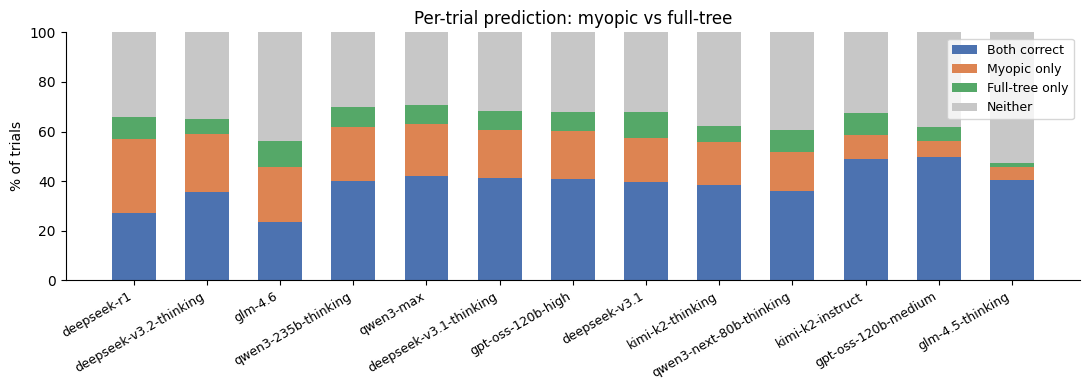

In [56]:
# Stacked accuracy bar
df_plot2 = df.sort_values('myopic_only', ascending=False).reset_index(drop=True)
colors_  = {'both':'#4C72B0','myopic_only':'#DD8452','full_only':'#55A868','neither':'#C7C7C7'}
labels_  = {'both':'Both correct','myopic_only':'Myopic only','full_only':'Full-tree only','neither':'Neither'}
fig, ax  = plt.subplots(figsize=(11, 4))
bottom   = np.zeros(len(df_plot2))
for key in ['both','myopic_only','full_only','neither']:
    vals = df_plot2[key].values * 100
    ax.bar(np.arange(len(df_plot2)), vals, bottom=bottom, color=colors_[key], label=labels_[key], width=0.6)
    bottom += vals
ax.set_xticks(np.arange(len(df_plot2)))
ax.set_xticklabels(df_plot2['short_name'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% of trials'); ax.legend(loc='upper right', fontsize=9); ax.set_ylim(0, 100)
ax.set_title('Per-trial prediction: myopic vs full-tree')
plt.tight_layout()
plt.savefig('figures/myopic_vs_fulltree_stacked.pdf', bbox_inches='tight')
plt.show()

In [57]:
FEATURES = [
    ('n_root',         'N root moves'),
    ('max_depth',      'Max tree depth'),
    ('avg_leaf_depth', 'Avg leaf depth'),
    ('n_nodes',        'N tree nodes'),
    ('n_empty',        'N empty squares'),
    ('q_gap_full',     'Q-gap (full-tree)'),
    ('q_gap_myopic',   'Q-gap (myopic)'),
]
feat_cols   = [col   for col, _     in FEATURES]
feat_labels = [label for _,   label in FEATURES]

# For each model: mean feature in full_only vs myopic_only trials
acc_diffs_by_model = {col: [] for col, _ in FEATURES}

for model in df_trial['model'].unique():
    mdf = df_trial[df_trial['model'] == model]
    grp_f = mdf[(mdf['full_ok'] == 1) & (mdf['myopic_ok'] == 0)]
    grp_m = mdf[(mdf['full_ok'] == 0) & (mdf['myopic_ok'] == 1)]
    if len(grp_f) < 3 or len(grp_m) < 3:
        continue
    for col, _ in FEATURES:
        acc_diffs_by_model[col].append(grp_f[col].mean() - grp_m[col].mean())

grp_full_only   = df_trial[(df_trial['full_ok'] == 1) & (df_trial['myopic_ok'] == 0)]
grp_myopic_only = df_trial[(df_trial['full_ok'] == 0) & (df_trial['myopic_ok'] == 1)]
print(f'full_only:   {len(grp_full_only)} trials')
print(f'myopic_only: {len(grp_myopic_only)} trials\n')

print('Mean feature value: full_only vs myopic_only trials')
print('Diff = full_only mean − myopic_only mean  (positive = higher when full-tree is uniquely correct)')
print('p-value: one-sample t-test on per-model differences (H0: mean diff = 0)\n')
rows = []
for col, label in FEATURES:
    gf = grp_full_only[col].mean()
    gm = grp_myopic_only[col].mean()
    diffs = np.array(acc_diffs_by_model[col])
    t, p = stats.ttest_1samp(diffs, popmean=0)
    rows.append({
        'Feature':             label,
        'Full-only mean':      f'{gf:.3f}',
        'Myopic-only mean':    f'{gm:.3f}',
        'Diff (F−M)':          f'{gf - gm:+.3f}',
        'mean diff (±SD)':     f'{diffs.mean():+.3f} (±{diffs.std():.3f})',
        't':                   f'{t:+.2f}',
        'p':                   f'{p:.3e}',
    })
display(pd.DataFrame(rows))

full_only:   512 trials
myopic_only: 1236 trials

Mean feature value: full_only vs myopic_only trials
Diff = full_only mean − myopic_only mean  (positive = higher when full-tree is uniquely correct)
p-value: one-sample t-test on per-model differences (H0: mean diff = 0)



,Feature,Full-only mean,Myopic-only mean,Diff (F−M),mean diff (±SD),t,p
0,N root moves,7.451,7.779,-0.328,-0.150 (±0.666),-0.78,4.506e-01
1,Max tree depth,1.508,1.636,-0.128,-0.048 (±0.248),-0.67,5.164e-01
2,Avg leaf depth,0.562,0.596,-0.034,-0.013 (±0.139),-0.32,7.536e-01
3,N tree nodes,13.055,14.103,-1.048,-0.608 (±1.091),-1.93,7.767e-02
4,N empty squares,28.232,28.576,-0.344,+0.115 (±1.816),+0.22,8.298e-01
5,Q-gap (full-tree),0.566,0.349,+0.218,+0.228 (±0.215),+3.68,3.127e-03
6,Q-gap (myopic),0.528,0.803,-0.274,-0.266 (±0.213),-4.34,9.653e-04


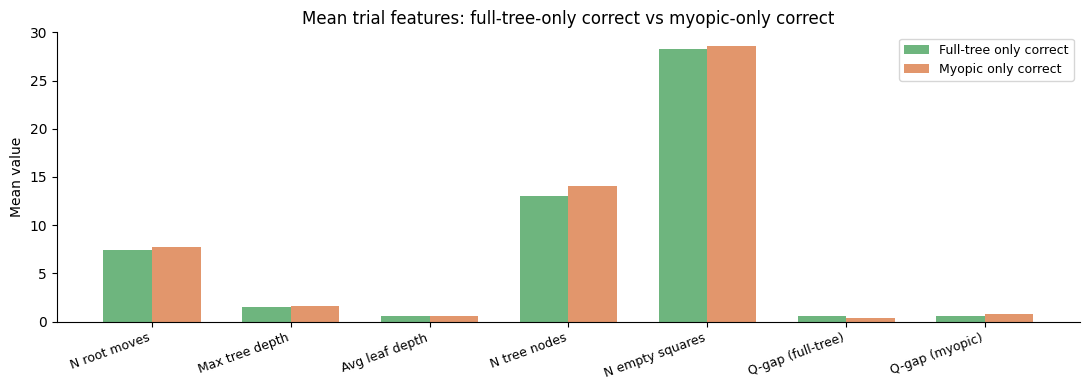

In [58]:
# Bar chart: full_only vs myopic_only by feature
means_full_only   = [grp_full_only[col].mean()   for col in feat_cols]
means_myopic_only = [grp_myopic_only[col].mean() for col in feat_cols]

x = np.arange(len(FEATURES))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, means_full_only,   width=w, color='#55A868', alpha=0.85, label='Full-tree only correct')
ax.bar(x + w/2, means_myopic_only, width=w, color='#DD8452', alpha=0.85, label='Myopic only correct')
ax.set_xticks(x)
ax.set_xticklabels(feat_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean value')
ax.legend(fontsize=9)
ax.set_title('Mean trial features: full-tree-only correct vs myopic-only correct')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/myopic_vs_fulltree_features_acc.pdf', bbox_inches='tight')
plt.show()